# IEEE-CIS Fraud Detection

## Notebook 4: Model Training

This notebook splits the data, encodes categorical features, handles class imbalance
with SMOTE, trains XGBoost and LightGBM models, evaluates performance using AUC-ROC,
explains predictions with SHAP values, and saves the final model and preprocessor.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score, classification_report
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import lightgbm as lgb
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 100)

In [2]:
df = pd.read_csv('/kaggle/input/notebooks/aliibtissam/03-feature-engineering/feature_engineered_data.csv')

print(f'Shape: {df.shape}')
print(f'Fraud rate: {df["isFraud"].mean() * 100:.2f}%')

Shape: (590540, 108)
Fraud rate: 3.50%


## 1. Train Test Split

We separate features from the target, then split into train and test sets.
Stratification ensures both sets maintain the original 3.5% fraud ratio.
The test set is never touched during training or preprocessing.

In [3]:
X = df.drop(columns=['isFraud', 'TransactionID'])
y = df['isFraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train size : {X_train.shape}')
print(f'Test size  : {X_test.shape}')
print(f'Train fraud rate: {y_train.mean() * 100:.2f}%')
print(f'Test fraud rate : {y_test.mean() * 100:.2f}%')

Train size : (472432, 106)
Test size  : (118108, 106)
Train fraud rate: 3.50%
Test fraud rate : 3.50%


## 2. Encoding Categorical Features

Label encoding converts string categories to integers so the model can process them.
We fit the encoder on training data only and apply it to both train and test
to prevent any test set information leaking into the encoding.

In [4]:
cat_cols = X_train.select_dtypes(include='object').columns.tolist()
print(f'Categorical columns to encode: {len(cat_cols)}')
print(cat_cols)

Categorical columns to encode: 28
['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_15', 'id_16', 'id_28', 'id_29', 'id_30', 'id_31', 'id_33', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo']


In [7]:
encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    
    # add 'unknown' to training data so the encoder always knows this category
    train_values = X_train[col].astype(str).tolist() + ['unknown']
    le.fit(train_values)
    
    X_train[col] = le.transform(X_train[col].astype(str))
    
    # replace unseen test categories with 'unknown' before transforming
    known_categories = set(le.classes_)
    X_test[col] = X_test[col].astype(str).apply(
        lambda x: x if x in known_categories else 'unknown'
    )
    X_test[col] = le.transform(X_test[col])
    encoders[col] = le

print('Encoding complete')
print(f'Train dtypes after encoding:\n{X_train.dtypes.value_counts()}')

Encoding complete
Train dtypes after encoding:
float64    72
int64      34
Name: count, dtype: int64


In [9]:
# fill remaining NaN values before SMOTE
# these come from identity columns that only exist for a subset of transactions
X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_train.median())

print(f'Missing values in X_train: {X_train.isnull().sum().sum()}')
print(f'Missing values in X_test: {X_test.isnull().sum().sum()}')

Missing values in X_train: 0
Missing values in X_test: 0


## 3. Handle Class Imbalance with SMOTE

SMOTE generates synthetic fraud transactions on the training set only.
The test set is never resampled — it must reflect real world distribution
to give an honest evaluation of model performance.

In [10]:
print(f'Before SMOTE - Train fraud rate: {y_train.mean() * 100:.2f}%')
print(f'Before SMOTE - Fraud count: {y_train.sum()}')
print(f'Before SMOTE - Legitimate count: {(y_train == 0).sum()}')

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f'\nAfter SMOTE - Train fraud rate: {y_train_resampled.mean() * 100:.2f}%')
print(f'After SMOTE - Fraud count: {y_train_resampled.sum()}')
print(f'After SMOTE - Legitimate count: {(y_train_resampled == 0).sum()}')

Before SMOTE - Train fraud rate: 3.50%
Before SMOTE - Fraud count: 16530
Before SMOTE - Legitimate count: 455902

After SMOTE - Train fraud rate: 50.00%
After SMOTE - Fraud count: 455902
After SMOTE - Legitimate count: 455902


## 4. Model Training

We train XGBoost and LightGBM on the SMOTE resampled training data.
scale_pos_weight is set to 1 since SMOTE already balanced the classes.
Both models are evaluated on the untouched test set using AUC-ROC.

In [11]:
# XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=1,
    random_state=42,
    eval_metric='auc',
    early_stopping_rounds=50,
    verbosity=0
)

xgb_model.fit(
    X_train_resampled, y_train_resampled,
    eval_set=[(X_test, y_test)],
    verbose=100
)

xgb_preds = xgb_model.predict_proba(X_test)[:, 1]
xgb_auc = roc_auc_score(y_test, xgb_preds)
print(f'XGBoost AUC-ROC: {xgb_auc:.4f}')

# LightGBM
lgb_model = lgb.LGBMClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=-1
)

lgb_model.fit(
    X_train_resampled, y_train_resampled,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(100)]
)

lgb_preds = lgb_model.predict_proba(X_test)[:, 1]
lgb_auc = roc_auc_score(y_test, lgb_preds)
print(f'LightGBM AUC-ROC: {lgb_auc:.4f}')

print(f'\nBest model: {"XGBoost" if xgb_auc > lgb_auc else "LightGBM"}')

[0]	validation_0-auc:0.80675
[100]	validation_0-auc:0.86429
[200]	validation_0-auc:0.88322
[300]	validation_0-auc:0.89490
[400]	validation_0-auc:0.90338
[499]	validation_0-auc:0.91069
XGBoost AUC-ROC: 0.9107
[100]	valid_0's binary_logloss: 0.187008
[200]	valid_0's binary_logloss: 0.140187
[300]	valid_0's binary_logloss: 0.121518
[400]	valid_0's binary_logloss: 0.107836
[500]	valid_0's binary_logloss: 0.0994408
LightGBM AUC-ROC: 0.9056

Best model: XGBoost


## 5. Model Explainability with SHAP

SHAP values explain why the model makes each prediction by quantifying
how much each feature pushed the prediction toward or away from fraud.

In [12]:
explainer = shap.TreeExplainer(xgb_model)

# use a sample of 5000 rows to keep computation fast
X_test_sample = X_test.sample(5000, random_state=42)
shap_values = explainer.shap_values(X_test_sample)

print(f'SHAP values shape: {shap_values.shape}')

SHAP values shape: (5000, 106)


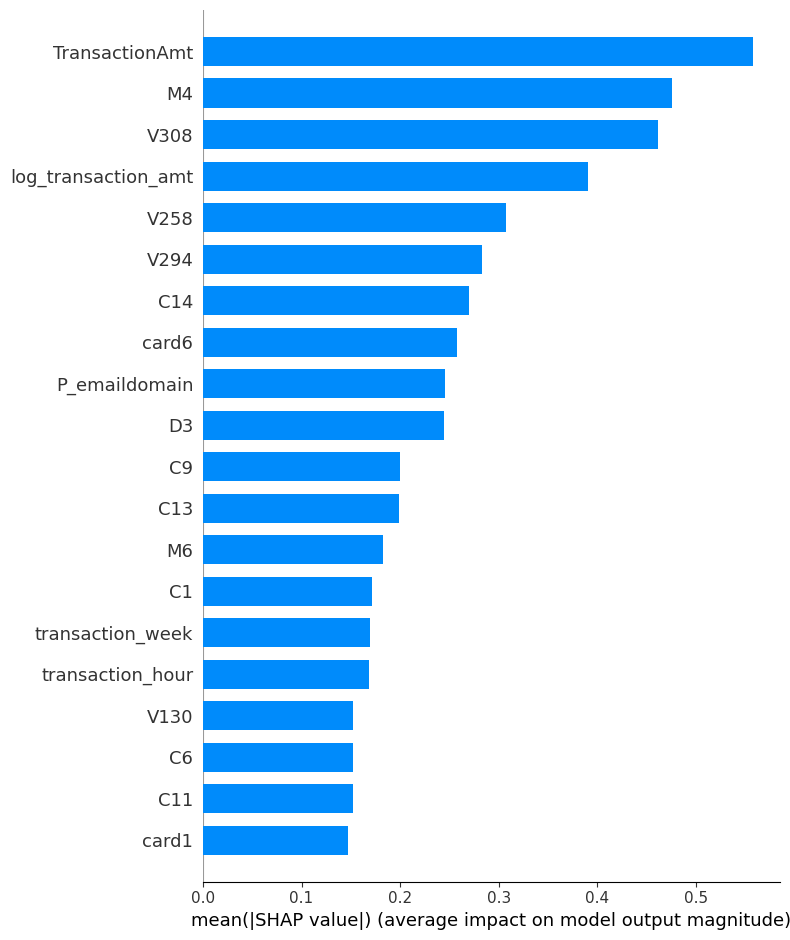

In [13]:
# global feature importance - which features matter most across all predictions
shap.summary_plot(shap_values, X_test_sample, plot_type='bar', max_display=20)

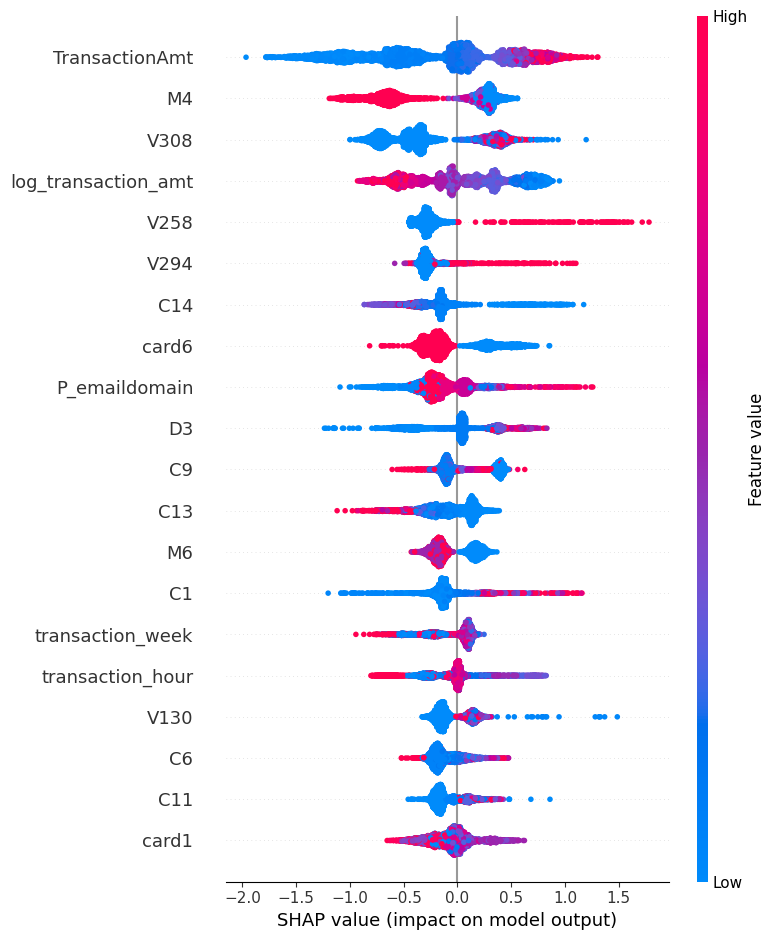

In [14]:
# dot plot shows direction of each feature's impact on fraud prediction
shap.summary_plot(shap_values, X_test_sample, max_display=20)

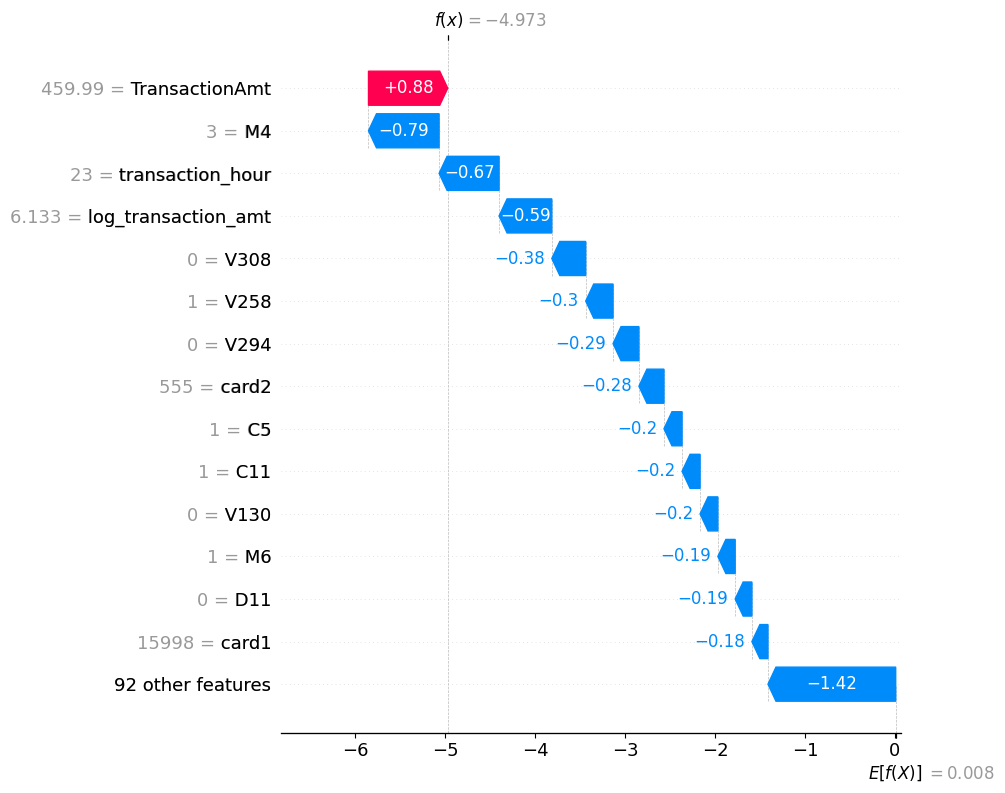

Actual label : 0
Model prediction probability: 0.0069


In [15]:
# explain a single transaction - pick the first row from our sample
idx = 0
single_transaction = X_test_sample.iloc[idx]
single_shap = shap_values[idx]

# waterfall plot for one transaction
shap.waterfall_plot(
    shap.Explanation(
        values=single_shap,
        base_values=explainer.expected_value,
        data=single_transaction,
        feature_names=X_test_sample.columns.tolist()
    ),
    max_display=15
)

print(f'Actual label : {y_test.iloc[idx]}')
print(f'Model prediction probability: {xgb_model.predict_proba(X_test_sample.iloc[[idx]])[:, 1][0]:.4f}')

## 6. Save Model and Preprocessor

We save the trained model, label encoders, and feature list.
These files will be downloaded and used by the FastAPI backend.

In [17]:
# save the trained xgboost model
joblib.dump(xgb_model, 'fraud_model.pkl')

# save the label encoders fitted on training data
joblib.dump(encoders, 'encoders.pkl')

# save the exact feature columns the model was trained on
# FastAPI must send data in exactly this column order
feature_columns = X_train.columns.tolist()
joblib.dump(feature_columns, 'feature_columns.pkl')

print('Saved: fraud_model.pkl')
print('Saved: encoders.pkl')
print('Saved: feature_columns.pkl')

Saved: fraud_model.pkl
Saved: encoders.pkl
Saved: feature_columns.pkl


## Summary

| Step | Detail |
|---|---|
| Train size | 472,432 transactions |
| Test size | 118,108 transactions |
| Categorical columns encoded | 28 |
| SMOTE - before | 3.5% fraud rate |
| SMOTE - after | 50% fraud rate (balanced) |
| XGBoost AUC-ROC | 0.9107 |
| LightGBM AUC-ROC | 0.9056 |
| Final model | XGBoost |
| Top feature | TransactionAmt |

The final model, encoders, and feature columns are saved as pkl files
and ready to be downloaded for the FastAPI backend.